# Clean DSMS vs GhostGUI plots

**Selected motions:** Pushup, Squat, Facedown, Lunges3 (**shown as Lunges**), Theworm.

Dependencies:

```text
numpy
matplotlib
```


This notebook generates only:

1. Reference jerk reduction
2. Clean-rollout tracking improvement
3. RL learning efficiency

In [1]:

from pathlib import Path
import csv
import math
import warnings

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CLEAN PRESENTATION CONFIG
# ============================================================
# Lunges3 is intentionally displayed as "Lunges" in all plots.
SELECTED_MOTIONS = ["Pushup", "Squat", "Facedown", "Lunges3", "Theworm"]
DISPLAY_NAME = {"Lunges3": "Lunges"}

PREFERRED_TRAINING_CONFIG = {
    "Pushup": "Custom",
    "Squat": "Custom",
    "Facedown": "Custom",
    "Lunges3": "Standard",
    "Theworm": "Standard",
}

GG_COLOR = "#8A8A8A"
DSMS_COLOR = "#2F6BFF"
STATE_COLOR = "#2F6BFF"
VELOCITY_COLOR = "#F28E2B"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def find_repo_root():
    """Find mjlab-trained whether run from repo root or notebooks/."""
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "logs" / "dsms_analysis").exists() and (p / "motion").exists():
            return p
    raise FileNotFoundError(
        "Could not find repo root. Run this notebook from mjlab-trained/ "
        "or mjlab-trained/notebooks/."
    )

def read_csv(path):
    with open(path, newline="") as f:
        return list(csv.DictReader(f))

def to_float(value, default=np.nan):
    try:
        if value is None or value == "" or str(value).lower() == "nan":
            return default
        return float(value)
    except (TypeError, ValueError):
        return default

def show_name(motion):
    return DISPLAY_NAME.get(motion, motion)

ROOT = find_repo_root()
EVAL_DIR = ROOT / "logs" / "dsms_analysis" / "eval_plots"
OUT_DIR = ROOT / "logs" / "dsms_analysis" / "clean_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_CSV = EVAL_DIR / "reference_quality.csv"
TRACE_CSV = EVAL_DIR / "all_trace_evaluation.csv"
LEARNING_CSV = EVAL_DIR / "learning_efficiency.csv"

for p in [REFERENCE_CSV, TRACE_CSV, LEARNING_CSV]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

reference = read_csv(REFERENCE_CSV)
traces = read_csv(TRACE_CSV)
learning = read_csv(LEARNING_CSV)

print("Repo root:", ROOT)
print("Output:", OUT_DIR)
print("Selected motions:", [show_name(m) for m in SELECTED_MOTIONS])


Repo root: /home/nathan/Desktop/mjlab-trained
Output: /home/nathan/Desktop/mjlab-trained/logs/dsms_analysis/clean_plots
Selected motions: ['Pushup', 'Squat', 'Facedown', 'Lunges', 'Theworm']


In [2]:

def paired_reference_metric(rows, metric):
    out = []

    for motion in SELECTED_MOTIONS:
        sub = [r for r in rows if r["motion"] == motion]
        gg = next((r for r in sub if r["condition"] == "GhostGUI"), None)
        ds = next((r for r in sub if r["condition"] == "DSMS"), None)

        if gg is None or ds is None:
            warnings.warn(f"Reference pair missing for {motion}; skipping.")
            continue

        gg_val = to_float(gg[metric])
        ds_val = to_float(ds[metric])

        out.append({
            "motion_internal": motion,
            "motion": show_name(motion),
            "GhostGUI": gg_val,
            "DSMS": ds_val,
            "reduction_percent": 100.0 * (gg_val - ds_val) / gg_val,
            "gg_duration_s": to_float(gg["duration_s"]),
            "dsms_duration_s": to_float(ds["duration_s"]),
        })

    return out


def choose_trace_pair(rows, motion):
    sub = [r for r in rows if r["motion"] == motion]
    if not sub:
        return None

    preferred = PREFERRED_TRAINING_CONFIG.get(motion)

    configs = []
    for r in sub:
        cfg = r.get("training_config")
        if cfg and cfg not in configs:
            configs.append(cfg)

    ordered_configs = []
    if preferred in configs:
        ordered_configs.append(preferred)
    ordered_configs += [c for c in configs if c != preferred]

    for cfg in ordered_configs:
        cfg_rows = [r for r in sub if r.get("training_config") == cfg]
        gg_rows = [r for r in cfg_rows if r.get("condition") == "GhostGUI"]
        ds_rows = [r for r in cfg_rows if r.get("condition") == "DSMS"]

        if not gg_rows or not ds_rows:
            continue

        gg_ckpts = {
            int(to_float(r["checkpoint_iteration"]))
            for r in gg_rows
            if not math.isnan(to_float(r["checkpoint_iteration"]))
        }
        ds_ckpts = {
            int(to_float(r["checkpoint_iteration"]))
            for r in ds_rows
            if not math.isnan(to_float(r["checkpoint_iteration"]))
        }

        shared = sorted(gg_ckpts & ds_ckpts)
        if not shared:
            continue

        ckpt = shared[-1]

        gg = next(
            r for r in gg_rows
            if int(to_float(r["checkpoint_iteration"])) == ckpt
        )
        ds = next(
            r for r in ds_rows
            if int(to_float(r["checkpoint_iteration"])) == ckpt
        )

        return gg, ds

    return None


def build_tracking_pairs(rows):
    out = []

    for motion in SELECTED_MOTIONS:
        pair = choose_trace_pair(rows, motion)

        if pair is None:
            warnings.warn(
                f"No matched clean rollout pair yet for {motion}. "
                "It will appear automatically after both traces are added."
            )
            continue

        gg, ds = pair

        def reduction(col):
            g = to_float(gg[col])
            d = to_float(ds[col])
            return 100.0 * (g - d) / g

        out.append({
            "motion_internal": motion,
            "motion": show_name(motion),
            "training_config": gg["training_config"],
            "checkpoint_iteration": int(to_float(gg["checkpoint_iteration"])),
            "position_rmse_reduction_percent": reduction("position_rmse_rad"),
            "velocity_rmse_reduction_percent": reduction("velocity_rmse_rad_s"),
            "state_rmse_reduction_percent": reduction("state_rmse_scaled"),
            "gg_state_rmse_scaled": to_float(gg["state_rmse_scaled"]),
            "dsms_state_rmse_scaled": to_float(ds["state_rmse_scaled"]),
            "gg_duration_s": to_float(gg["duration_s"]),
            "dsms_duration_s": to_float(ds["duration_s"]),
        })

    order = {m: i for i, m in enumerate(SELECTED_MOTIONS)}
    out.sort(key=lambda r: order[r["motion_internal"]])
    return out


def choose_learning_row(rows, motion, condition):
    sub = [
        r for r in rows
        if r["motion"] == motion and r["condition"] == condition
    ]

    if not sub:
        return None

    preferred = PREFERRED_TRAINING_CONFIG.get(motion)
    preferred_rows = [
        r for r in sub
        if r.get("training_config") == preferred
    ]

    if preferred_rows:
        sub = preferred_rows

    source_rank = {"tensorboard": 0, "wandb": 1}

    sub.sort(
        key=lambda r: (
            source_rank.get(r.get("source"), 9),
            -to_float(r.get("final_iteration"), default=-1),
        )
    )

    return sub[0]


def build_learning_pairs(rows):
    out = []

    for motion in SELECTED_MOTIONS:
        for condition in ["GhostGUI", "DSMS"]:
            row = choose_learning_row(rows, motion, condition)

            if row is None:
                warnings.warn(f"Learning result missing for {motion} / {condition}; skipping.")
                continue

            threshold = to_float(row.get("iterations_to_reward_30"))
            final_iteration = to_float(row.get("final_iteration"))
            threshold_reached = not math.isnan(threshold)

            out.append({
                "motion_internal": motion,
                "motion": show_name(motion),
                "condition": condition,
                "training_config": row.get("training_config"),
                "source": row.get("source"),
                "final_iteration": final_iteration,
                "final_1k_mean_reward": to_float(row.get("final_1k_mean_reward")),
                "iterations_to_reward_30": threshold,
                "threshold_reached": threshold_reached,
                "threshold_plot_value": threshold if threshold_reached else final_iteration,
            })

    order = {m: i for i, m in enumerate(SELECTED_MOTIONS)}
    condition_order = {"GhostGUI": 0, "DSMS": 1}

    out.sort(
        key=lambda r: (
            order[r["motion_internal"]],
            condition_order[r["condition"]],
        )
    )

    return out


reference_pairs = paired_reference_metric(reference, "jerk_rms_rad_s3")
tracking_pairs = build_tracking_pairs(traces)
learning_pairs = build_learning_pairs(learning)

print("\nReference pairs:")
for r in reference_pairs:
    print(r)

print("\nTracking pairs:")
for r in tracking_pairs:
    print(r)

print("\nLearning pairs:")
for r in learning_pairs:
    print(r)



Reference pairs:
{'motion_internal': 'Pushup', 'motion': 'Pushup', 'GhostGUI': 229.6087148163137, 'DSMS': 66.1095559618602, 'reduction_percent': 71.20773224363559, 'gg_duration_s': 2.98, 'dsms_duration_s': 4.18}
{'motion_internal': 'Squat', 'motion': 'Squat', 'GhostGUI': 491.90913640279626, 'DSMS': 32.418574450116246, 'reduction_percent': 93.40964173034376, 'gg_duration_s': 1.48, 'dsms_duration_s': 2.98}
{'motion_internal': 'Facedown', 'motion': 'Facedown', 'GhostGUI': 209.47873283397672, 'DSMS': 221.54298251302987, 'reduction_percent': -5.759176368808151, 'gg_duration_s': 4.98, 'dsms_duration_s': 4.98}
{'motion_internal': 'Lunges3', 'motion': 'Lunges', 'GhostGUI': 937.0332453879473, 'DSMS': 220.43252528918725, 'reduction_percent': 76.47548511494654, 'gg_duration_s': 3.38, 'dsms_duration_s': 3.38}
{'motion_internal': 'Theworm', 'motion': 'Theworm', 'GhostGUI': 3043.979991891921, 'DSMS': 1249.8005906549397, 'reduction_percent': 58.94189206289255, 'gg_duration_s': 2.34, 'dsms_duration_s

/tmp/ipykernel_1477382/760459696.py:93: UserWarning: No matched clean rollout pair yet for Lunges3. It will appear automatically after both traces are added.
  warnings.warn(


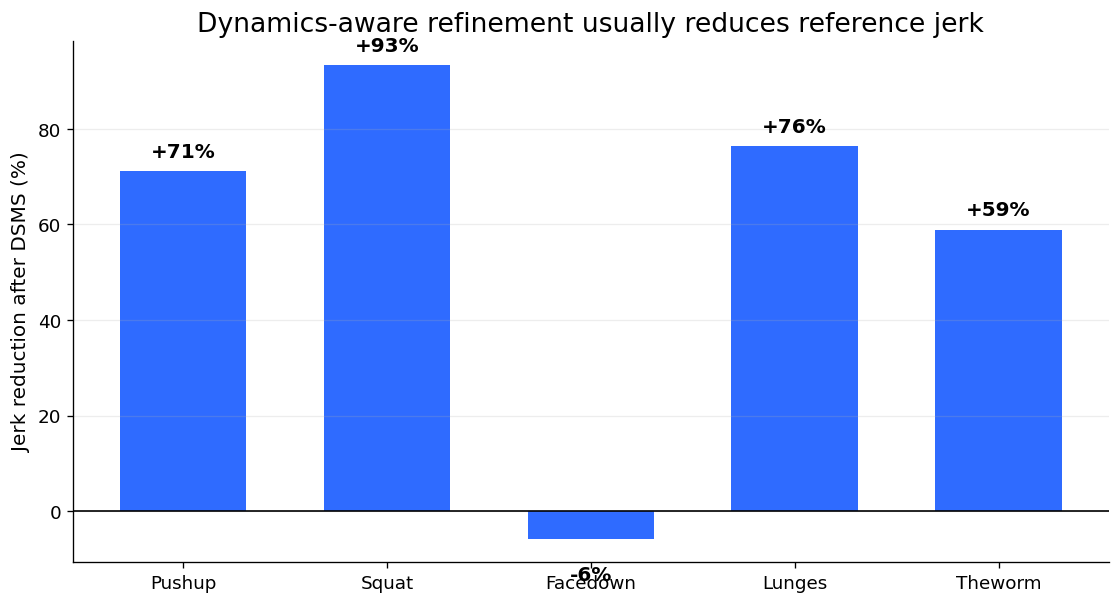

Saved: /home/nathan/Desktop/mjlab-trained/logs/dsms_analysis/clean_plots/01_reference_jerk_reduction.png


In [3]:

# ============================================================
# FIGURE 1 — REFERENCE QUALITY
# ============================================================
# Positive = DSMS reduced jerk.
# Negative = DSMS increased jerk.

plot_rows = reference_pairs
x = np.arange(len(plot_rows))
values = [r["reduction_percent"] for r in plot_rows]
labels = [r["motion"] for r in plot_rows]

fig, ax = plt.subplots(figsize=(9.5, 5.2))

bars = ax.bar(
    x,
    values,
    width=0.62,
    color=DSMS_COLOR,
)

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Jerk reduction after DSMS (%)")
ax.set_title("Dynamics-aware refinement usually reduces reference jerk")
ax.grid(axis="y", alpha=0.22)

for bar, value in zip(bars, values):
    ax.annotate(
        f"{value:+.0f}%",
        (bar.get_x() + bar.get_width() / 2, value),
        xytext=(0, 6 if value >= 0 else -16),
        textcoords="offset points",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontweight="bold",
    )

fig.tight_layout()

path = OUT_DIR / "01_reference_jerk_reduction.png"
fig.savefig(path, bbox_inches="tight")
plt.show()

print("Saved:", path)


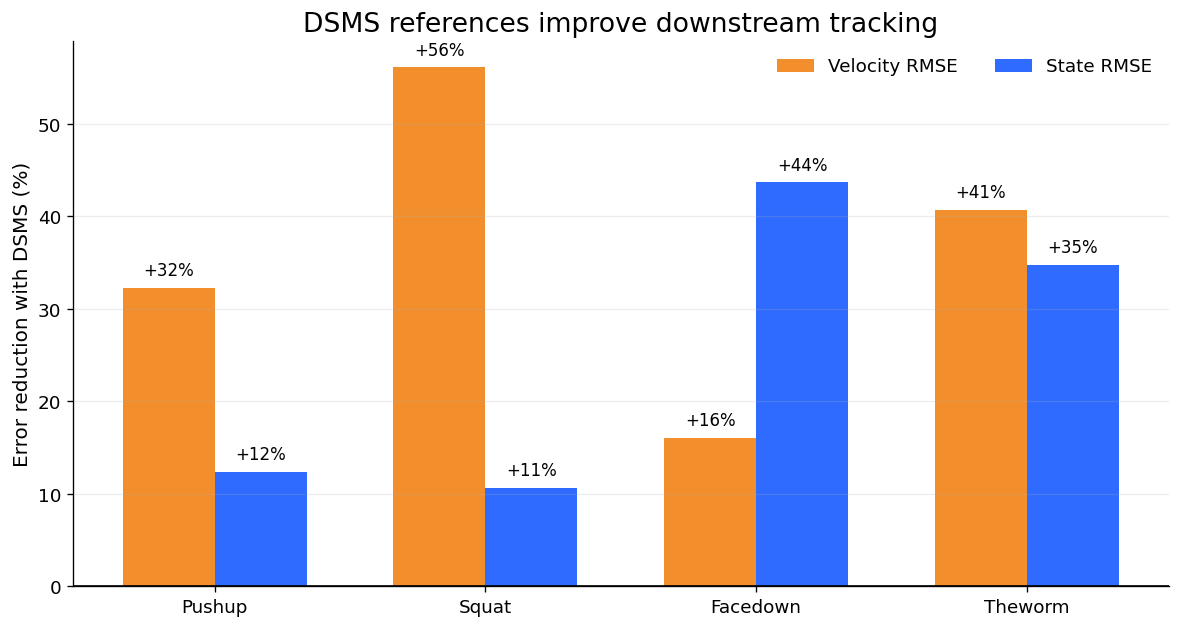

Saved: /home/nathan/Desktop/mjlab-trained/logs/dsms_analysis/clean_plots/02_tracking_improvement.png
Waiting for matched clean rollout traces: Lunges


In [4]:

# ============================================================
# FIGURE 2 — CLEAN-ROLLOUT TRACKING
# ============================================================
# Positive = DSMS has lower error than GhostGUI.
#
# Lunges appears automatically once the Lunges3 GG + DSMS
# rollout pair exists in all_trace_evaluation.csv.

if not tracking_pairs:
    print("No matched clean rollout pairs available yet.")
else:
    labels = [r["motion"] for r in tracking_pairs]
    velocity = [r["velocity_rmse_reduction_percent"] for r in tracking_pairs]
    state = [r["state_rmse_reduction_percent"] for r in tracking_pairs]

    x = np.arange(len(labels))
    width = 0.34

    fig, ax = plt.subplots(figsize=(10, 5.4))

    b1 = ax.bar(
        x - width / 2,
        velocity,
        width,
        label="Velocity RMSE",
        color=VELOCITY_COLOR,
    )

    b2 = ax.bar(
        x + width / 2,
        state,
        width,
        label="State RMSE",
        color=STATE_COLOR,
    )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Error reduction with DSMS (%)")
    ax.set_title("DSMS references improve downstream tracking")
    ax.legend(frameon=False, ncol=2)
    ax.grid(axis="y", alpha=0.22)

    for bars in [b1, b2]:
        for bar in bars:
            value = bar.get_height()
            ax.annotate(
                f"{value:+.0f}%",
                (bar.get_x() + bar.get_width() / 2, value),
                xytext=(0, 5 if value >= 0 else -14),
                textcoords="offset points",
                ha="center",
                va="bottom" if value >= 0 else "top",
                fontsize=10,
            )

    fig.tight_layout()

    path = OUT_DIR / "02_tracking_improvement.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()

    print("Saved:", path)

present = {r["motion_internal"] for r in tracking_pairs}
missing = [show_name(m) for m in SELECTED_MOTIONS if m not in present]

if missing:
    print("Waiting for matched clean rollout traces:", ", ".join(missing))


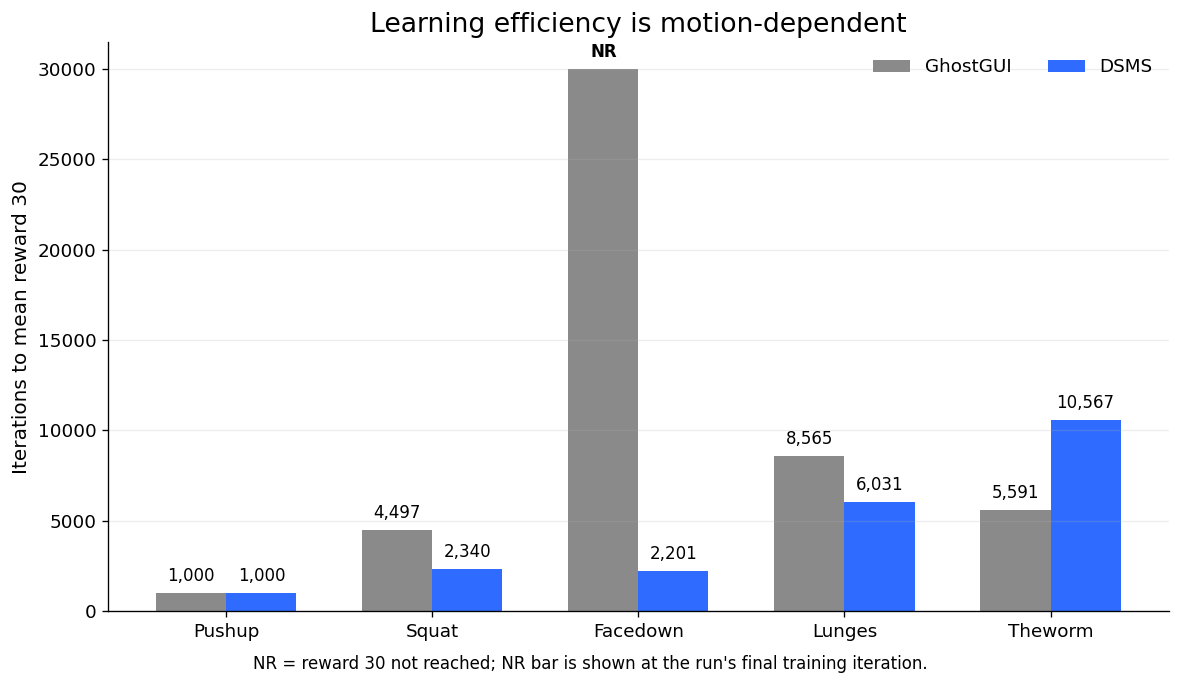

Saved: /home/nathan/Desktop/mjlab-trained/logs/dsms_analysis/clean_plots/03_learning_efficiency.png


In [5]:

# ============================================================
# FIGURE 3 — LEARNING EFFICIENCY
# ============================================================
# Lower is better.
#
# If reward 30 was never reached, the bar is drawn at the final
# training iteration and labelled "NR".

motions_present = []

for motion in SELECTED_MOTIONS:
    conditions = {
        r["condition"]
        for r in learning_pairs
        if r["motion_internal"] == motion
    }

    if {"GhostGUI", "DSMS"}.issubset(conditions):
        motions_present.append(motion)

if not motions_present:
    print("No paired learning summaries available.")
else:
    labels = [show_name(m) for m in motions_present]
    gg_rows = []
    ds_rows = []

    for motion in motions_present:
        gg_rows.append(
            next(
                r for r in learning_pairs
                if r["motion_internal"] == motion and r["condition"] == "GhostGUI"
            )
        )
        ds_rows.append(
            next(
                r for r in learning_pairs
                if r["motion_internal"] == motion and r["condition"] == "DSMS"
            )
        )

    x = np.arange(len(labels))
    width = 0.34

    fig, ax = plt.subplots(figsize=(10, 5.6))

    b_gg = ax.bar(
        x - width / 2,
        [r["threshold_plot_value"] for r in gg_rows],
        width,
        label="GhostGUI",
        color=GG_COLOR,
    )

    b_ds = ax.bar(
        x + width / 2,
        [r["threshold_plot_value"] for r in ds_rows],
        width,
        label="DSMS",
        color=DSMS_COLOR,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Iterations to mean reward 30")
    ax.set_title("Learning efficiency is motion-dependent")
    ax.legend(frameon=False, ncol=2)
    ax.grid(axis="y", alpha=0.22)

    for bars, rows in [(b_gg, gg_rows), (b_ds, ds_rows)]:
        for bar, row in zip(bars, rows):
            if row["threshold_reached"]:
                label = f"{int(row['iterations_to_reward_30']):,}"
            else:
                label = "NR"

            ax.annotate(
                label,
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold" if label == "NR" else "normal",
            )

    fig.text(
        0.5,
        -0.01,
        "NR = reward 30 not reached; NR bar is shown at the run's final training iteration.",
        ha="center",
        fontsize=10,
    )

    fig.tight_layout()

    path = OUT_DIR / "03_learning_efficiency.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()

    print("Saved:", path)


In [6]:

# ============================================================
# COMPACT SUMMARY CSV — NO PANDAS
# ============================================================

tracking_by_motion = {r["motion_internal"]: r for r in tracking_pairs}

learning_lookup = {
    (r["motion_internal"], r["condition"]): r
    for r in learning_pairs
}

summary_rows = []

for ref in reference_pairs:
    motion = ref["motion_internal"]
    track = tracking_by_motion.get(motion)
    gg_learn = learning_lookup.get((motion, "GhostGUI"))
    ds_learn = learning_lookup.get((motion, "DSMS"))

    summary_rows.append({
        "motion": ref["motion"],
        "jerk_reduction_percent": ref["reduction_percent"],
        "gg_duration_s": ref["gg_duration_s"],
        "dsms_duration_s": ref["dsms_duration_s"],
        "velocity_rmse_reduction_percent":
            track["velocity_rmse_reduction_percent"] if track else "",
        "state_rmse_reduction_percent":
            track["state_rmse_reduction_percent"] if track else "",
        "gg_iterations_to_reward_30":
            gg_learn["iterations_to_reward_30"]
            if gg_learn and gg_learn["threshold_reached"] else "",
        "dsms_iterations_to_reward_30":
            ds_learn["iterations_to_reward_30"]
            if ds_learn and ds_learn["threshold_reached"] else "",
    })

summary_path = OUT_DIR / "selected_motion_summary.csv"

fieldnames = [
    "motion",
    "jerk_reduction_percent",
    "gg_duration_s",
    "dsms_duration_s",
    "velocity_rmse_reduction_percent",
    "state_rmse_reduction_percent",
    "gg_iterations_to_reward_30",
    "dsms_iterations_to_reward_30",
]

with open(summary_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(summary_rows)

print("Saved:", summary_path)

print("\nSummary:")
for row in summary_rows:
    print(row)

print("\nGenerated figures:")
for p in sorted(OUT_DIR.glob("*.png")):
    print(" -", p.name)


Saved: /home/nathan/Desktop/mjlab-trained/logs/dsms_analysis/clean_plots/selected_motion_summary.csv

Summary:
{'motion': 'Pushup', 'jerk_reduction_percent': 71.20773224363559, 'gg_duration_s': 2.98, 'dsms_duration_s': 4.18, 'velocity_rmse_reduction_percent': 32.29378767676595, 'state_rmse_reduction_percent': 12.397056030742728, 'gg_iterations_to_reward_30': 1000.0, 'dsms_iterations_to_reward_30': 1000.0}
{'motion': 'Squat', 'jerk_reduction_percent': 93.40964173034376, 'gg_duration_s': 1.48, 'dsms_duration_s': 2.98, 'velocity_rmse_reduction_percent': 56.13498247811211, 'state_rmse_reduction_percent': 10.68082750374745, 'gg_iterations_to_reward_30': 4497.0, 'dsms_iterations_to_reward_30': 2340.0}
{'motion': 'Facedown', 'jerk_reduction_percent': -5.759176368808151, 'gg_duration_s': 4.98, 'dsms_duration_s': 4.98, 'velocity_rmse_reduction_percent': 16.03810531981894, 'state_rmse_reduction_percent': 43.70884439363524, 'gg_iterations_to_reward_30': '', 'dsms_iterations_to_reward_30': 2201.0}